In [37]:
import xarray as xr
import sys 
import os
os.chdir("../")
import lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from src.models.model import SimpleMLP
from src.data.datamodule import CustomDataModule
from src.models.lightning_module import RainfallRegressionModel
from src.utils.config import load_config
import argparse
import os
import pandas as pd

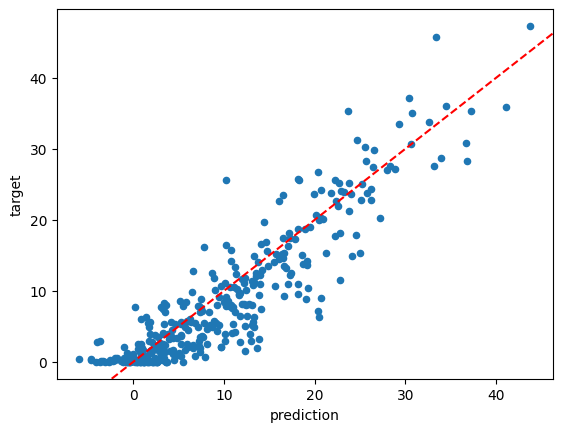

In [ ]:
df = pd.read_csv("/Users/robin/Library/CloudStorage/OneDrive-UniversityofBergen/Documents/Travail/Cours/2026 - ML BCCR Course/course_git/BCCR-ml-project-example/outputs/bccr-ml-course/iprziwi7/predictions.csv", index_col=0, parse_dates=True)

df.query("data_slice == 'test'").plot(x='prediction', y='target', kind='scatter')
plt.axline((0,0), slope=1, color='red', linestyle='--')

In [2]:
config = load_config('configs/experiments/default.yml')

wandb_logger = WandbLogger(
    project=config['logging']['project'],
    name=config['logging'].get('run_name'),
    config=config,
    save_dir=config['logging']['base_dir']
)

run_id = wandb_logger.experiment.id
out_dir = f"{config['logging']['base_dir']}/{config['logging']['project']}/{run_id}"

datamodule = CustomDataModule(
    data_in_path=config['data']['input_path'],
    data_target_path=config['data']['target_path'],
    batch_size=config['data']['batch_size']
)

image_size = datamodule.image_shape[1]*datamodule.image_shape[2]

model = SimpleMLP(input_size=image_size, 
                    hidden_size=config['model']['hidden_size'], 
                    target_size=1)

lightning_model = RainfallRegressionModel(model, learning_rate=config['trainer']['learning_rate'])

checkpoint_callback = ModelCheckpoint(
    dirpath=os.path.join(out_dir, "checkpoints"),
    filename="best",
    monitor="val_loss",
    save_top_k=1,
    mode="min",
)

trainer = L.Trainer(
    max_epochs=config['trainer']['max_epochs'],
    logger=wandb_logger,
    default_root_dir=out_dir,
    callbacks=[checkpoint_callback],
)

trainer.fit(lightning_model, datamodule=datamodule)
trainer.validate(lightning_model, datamodule=datamodule)




wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/robin/.netrc.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type      | Params | Mode  | FLOPs
--------------------------------------------------------
0 | model     | SimpleMLP | 262 K  | train | 0    
1 | criterion | MSELoss   | 0      | train | 0    
--------------------------------------------------------
262 K     Trainable params
0         Non-trainable params
262 K     Total params
1.049     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops


/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 

Epoch 19: 100%|██████████| 93/93 [00:00<00:00, 107.45it/s, v_num=fojg, val_loss=24.30, val_r2=0.723]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 93/93 [00:00<00:00, 106.43it/s, v_num=fojg, val_loss=24.30, val_r2=0.723]


/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 149.13it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        val_loss            24.308313369750977
         val_r2             0.7233645915985107
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 24.308313369750977, 'val_r2': 0.7233645915985107}]

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


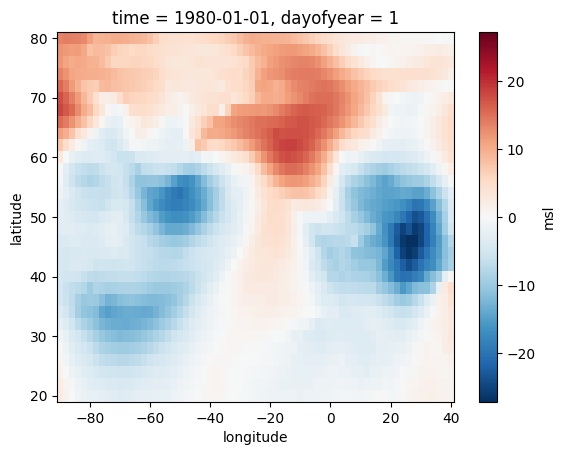

In [ ]:
ds = xr.open_dataset(config['data']['input_path'])

ds.msl.isel(time=0).plot()

In [23]:
all_predictions = []
all_targets = []
for prediction, target in trainer.predict(lightning_model, datamodule=datamodule):
    all_predictions.append(prediction)
    all_targets.append(target)
predictions = torch.cat(all_predictions, dim=0)
targets = torch.cat(all_targets, dim=0)

/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 142.39it/s]


In [24]:
plt.plot(targets)

NameError: name 'plt' is not defined

In [3]:
import torch
predictions = torch.cat(trainer.predict(lightning_model, datamodule=datamodule), dim=0)
predictions

/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 118.03it/s]


TypeError: expected Tensor as element 0 in argument 0, but got tuple

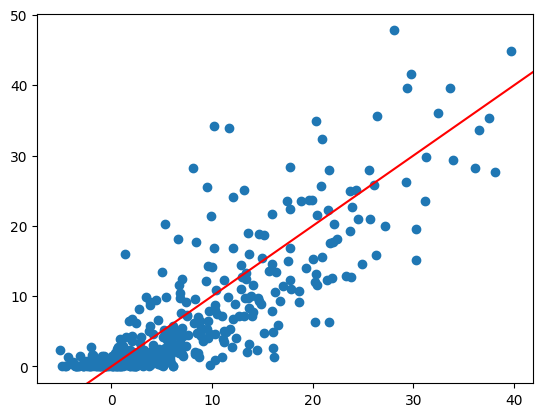

In [30]:
import matplotlib.pyplot as plt
plt.scatter(predictions, targets)
plt.axline((0,0),(1,1), color='red')


In [16]:
from src.models.model import SimpleMLP
from src.data.dataset import CustomDataset
from src.data.datamodule import CustomDataModule
from src.models.lightning_module import RainfallRegressionModel
from src.utils.config import load_config

In [18]:
load_config('../configs/experiments/default.yml')

{'model': {'input_channels': 1, 'hidden_size': 128},
 'data': {'input_path': 'data/raw/msl_data_northatlantic.nc',
  'target_path': 'data/raw/pr_era5_daily_westnorway_1940-2024.nc',
  'batch_size': 128,
  'num_workers': 4},
 'trainer': {'max_epochs': 50,
  'learning_rate': 0.001,
  'accelerator': 'gpu',
  'devices': 1},
 'logging': {'project': 'extreme-rainfall', 'run_name': 'baseline'}}

In [3]:
datamodule = CustomDataModule(
    data_in_path="../data/raw/msl_data_northatlantic.nc",
    data_out_path="../data/raw/pr_era5_daily_westnorway_1940-2024.nc",
    batch_size=128)

In [4]:
dataset = CustomDataset(
    ds_in_path="../data/raw/msl_data_northatlantic.nc",
    ds_out_path="../data/raw/pr_era5_daily_westnorway_1940-2024.nc",)

In [ ]:
model = SimpleMLP(input_size=datamodule.image_shape[1]*datamodule.image_shape[2], hidden_size=64, output_size=1)
lightning_model = RainfallRegressionModel(model, learning_rate=1e-3)
trainer = L.Trainer(max_epochs=20)
lightning_model.train()
trainer.fit(lightning_model, datamodule=datamodule)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type      | Params | Mode  | FLOPs
--------------------------------------------------------
0 | model     | SimpleMLP | 131 K  | train | 0    
1 | criterion | MSELoss   | 0      | train | 0    
--------------------------------------------------------
131 K     Trainable params
0         Non-trainable params
131 K     Total params
0.524     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (24) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [9]:
trainer.validate(lightning_model, datamodule=datamodule)

/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        val_loss             31.75809669494629
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 31.75809669494629}]